In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Linear Regression – Hồi quy tuyến tính


## 1. Mô hình
Linear regression giả định mối quan hệ tuyến tính giữa đầu vào $x$ và đầu ra $y$:

$$ \hat{y} = w_0 + w_1x_1 + w_2x_2 + \cdots + w_nx_n = \mathbf{w}^T\mathbf{x} + b $$

Dạng ma trận (thêm cột bias vào $X$):

$$ \hat{\mathbf{y}} = X\mathbf{w} $$

Mục tiêu: tìm $\mathbf{w}$ sao cho $\hat{y}$ gần với $y$ thật nhất.


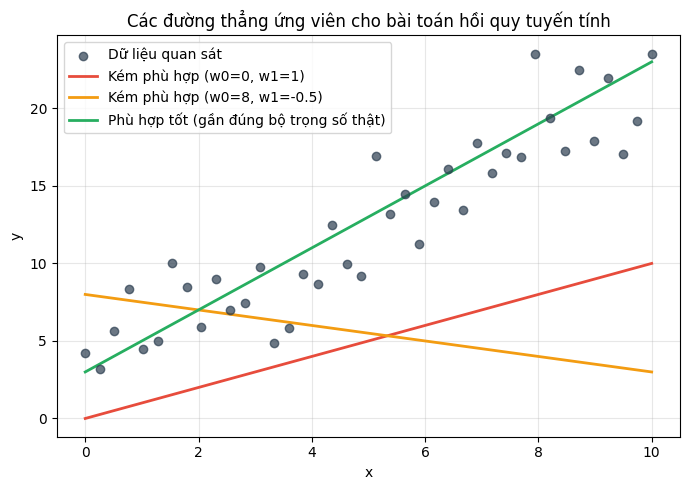

In [ ]:
np.random.seed(42)
n_samples = 40
x_demo = np.linspace(0, 10, n_samples)
y_demo = 3 + 2 * x_demo + np.random.normal(0, 2.5, n_samples)

candidates = [
    (0, 1, "Kém phù hợp (w0=0, w1=1)"),
    (8, -0.5, "Kém phù hợp (w0=8, w1=-0.5)"),
    (3, 2, "Phù hợp tốt (gần đúng bộ trọng số thật)"),
]
colors = ["#e74c3c", "#f39c12", "#27ae60"]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x_demo, y_demo, color="#2c3e50", alpha=0.7, label="Dữ liệu quan sát", zorder=3)

for (w0, w1, label), color in zip(candidates, colors):
    ax.plot(x_demo, w0 + w1 * x_demo, color=color, linewidth=2, label=label)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Các đường thẳng ứng viên cho bài toán hồi quy tuyến tính")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 2. Bài toán áp dụng

- **Supervised learning – regression**: đầu ra $y$ là một biến liên tục (giá nhà, giá cổ phiếu, doanh thu, ...).
- **Điều kiện phù hợp**: mối quan hệ giữa $x$ và $y$ xấp xỉ tuyến tính, hoặc có thể tuyến tính hóa thông qua feature engineering (polynomial features, log-transform, ...).
- **Không phù hợp** khi quan hệ phi tuyến mạnh và không thể tuyến tính hóa, hoặc khi $y$ là biến rời rạc/phân loại (lúc đó cần các mô hình classification thay vì regression).

## 3. Hàm mất mát

Giá trị thực tế sẽ sai khác so với giá trị mô hình dự đoán một lượng nhiễu $\epsilon_i$:
$$y_i = \hat{y}_i + \epsilon_i$$

Giả định nhiễu có phân bố chuẩn: $\epsilon_i \sim N(0, \sigma^2)$

$\Rightarrow y_i$ cũng có phân bố chuẩn: $y_i \sim N(\hat{y}_i, \sigma^2)$, suy ra xác suất mô hình dự đoán đúng giá trị $y_i$:
$$P(y_i \mid x_i; W) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( - \frac{(y_i - \hat{y}_i)^2}{2\sigma^2} \right)$$

Hàm Likelihood có điều kiện:
$$L(W) = \prod_{i=1}^{N} P(y_i \mid x_i; W)$$
$$\Rightarrow \ln L(W) = \sum_{i=1}^{N} \ln \left[ \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( - \frac{(y_i - \hat{y}_i)^2}{2\sigma^2} \right) \right]$$
$$\Rightarrow \ln L(W) = \sum_{i=1}^{N} \left[ \ln\left(\frac{1}{\sqrt{2\pi\sigma^2}}\right) - \frac{(y_i - \hat{y}_i)^2}{2\sigma^2} \right]$$
$$\Rightarrow \ln L(W) = N \ln\left(\frac{1}{\sqrt{2\pi\sigma^2}}\right) - \frac{1}{2\sigma^2} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$$

MLE: $$\arg\max_{W} \ln L(W) \iff \arg\min_{W} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$$

$SSE = \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$, suy ra cần tối thiểu hóa hàm mất mát $MSE = \dfrac{1}{N}\sum_{i=1}^{N} (y_i - \hat{y}_i)^2$.

**Vì sao dùng MSE thay vì SSE?**
- Giá trị của SSE phụ thuộc trực tiếp vào kích thước tập dữ liệu ($N$). Khi $N$ càng lớn, phép cộng dồn khiến SSE càng tăng.
- Do đó, SSE không phản ánh khách quan độ chính xác thực sự của mô hình khi so sánh trên các tập dữ liệu có kích thước khác nhau.
- Việc chia cho $N$ (để có MSE) giúp chuẩn hóa sai số trên mỗi điểm dữ liệu, tạo ra một thước đo công bằng và ổn định hơn.

**Ví dụ minh họa:**
- Mô hình A (huấn luyện trên 100 căn nhà): $SSE = 200 \rightarrow MSE = \frac{200}{100} = 2$.
- Mô hình B (huấn luyện trên 10.000 căn nhà): $SSE = 5000 \rightarrow MSE = \frac{5000}{10000} = 0.5$.

Nếu chỉ dựa vào SSE, ta dễ kết luận sai rằng Mô hình A tốt hơn ($200 < 5000$). Tuy nhiên, thước đo chuẩn hóa MSE cho thấy Mô hình B có độ chính xác cao hơn gấp 4 lần ($0.5 < 2$).

## 4. Phương pháp tối ưu tham số

### 4.1. Normal Equation

$$\hat{\mathbf{y}} = \mathbf{X}\mathbf{w}$$

Trong đó $\mathbf{X}$ là ma trận kích thước $N \times (p + 1)$, $\mathbf{w}$ là vector cột kích thước $(p+1) \times 1$, và $\mathbf{y} = [y_1, y_2, \dots, y_N]^T$ là vector cột chứa $N$ giá trị thực tế.

Cần tối thiểu hóa hàm mất mát:
$$MSE(\mathbf{w}) = \frac{1}{N} (\mathbf{y} - \mathbf{X}\mathbf{w})^T (\mathbf{y} - \mathbf{X}\mathbf{w})$$

Khai triển biểu thức bên trong:
$$MSE(\mathbf{w}) = \frac{1}{N} \left[ (\mathbf{y}^T - \mathbf{w}^T \mathbf{X}^T) (\mathbf{y} - \mathbf{X}\mathbf{w}) \right]$$
$$MSE(\mathbf{w}) = \frac{1}{N} \left[ \mathbf{y}^T\mathbf{y} - \mathbf{w}^T\mathbf{X}^T\mathbf{y} - \mathbf{y}^T\mathbf{X}\mathbf{w} + \mathbf{w}^T\mathbf{X}^T\mathbf{X}\mathbf{w} \right]$$

Phân tích kích thước của cụm $\mathbf{w}^T\mathbf{X}^T\mathbf{y}$:
- $\mathbf{w}^T$: $1 \times (p+1)$
- $\mathbf{X}^T$: $(p+1) \times N$
- $\mathbf{y}$: $N \times 1$

Suy ra $\mathbf{w}^T\mathbf{X}^T\mathbf{y}$ là một số vô hướng (kích thước $1 \times 1$). Vì chuyển vị của một số vô hướng bằng chính nó:
$$(\mathbf{w}^T\mathbf{X}^T\mathbf{y})^T = \mathbf{y}^T\mathbf{X}\mathbf{w} = \mathbf{w}^T\mathbf{X}^T\mathbf{y}$$

Do đó, hàm mất mát được gộp lại thành:
$$MSE(\mathbf{w}) = \frac{1}{N} \left[ \mathbf{y}^T\mathbf{y} - 2\mathbf{w}^T\mathbf{X}^T\mathbf{y} + \mathbf{w}^T\mathbf{X}^T\mathbf{X}\mathbf{w} \right]$$

Lấy đạo hàm của $MSE(\mathbf{w})$ theo vector $\mathbf{w}$:
$$\frac{\partial MSE}{\partial \mathbf{w}} = \frac{1}{N} \left[ -2\mathbf{X}^T\mathbf{y} + 2\mathbf{X}^T\mathbf{X}\mathbf{w} \right] = \frac{2}{N} \left( \mathbf{X}^T\mathbf{X}\mathbf{w} - \mathbf{X}^T\mathbf{y} \right)$$

Cho đạo hàm bằng 0 để tìm điểm cực tiểu:
$$\frac{2}{N} \left( \mathbf{X}^T\mathbf{X}\mathbf{w} - \mathbf{X}^T\mathbf{y} \right) = 0 \;\Rightarrow\; \mathbf{X}^T\mathbf{X}\mathbf{w} = \mathbf{X}^T\mathbf{y}$$

Nhân cả hai vế với ma trận nghịch đảo $(\mathbf{X}^T\mathbf{X})^{-1}$, ta thu được công thức **Normal Equation**:
$$\mathbf{w} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$$

- **Ưu điểm**: nghiệm chính xác (closed-form), không cần chọn learning rate.
- **Nhược điểm**: độ phức tạp $O(p^3)$ khi nghịch đảo ma trận $(p+1) \times (p+1)$ $\Rightarrow$ chậm khi số features lớn, và không tính được nếu $\mathbf{X}^T\mathbf{X}$ suy biến (không khả nghịch).

### 4.2. Gradient Descent

$$\mathbf{w} \leftarrow \mathbf{w} - \alpha \left[ \frac{2}{N} \mathbf{X}^T (\mathbf{X}\mathbf{w} - \mathbf{y}) \right]$$

Khi số feature ($p$) hoặc số mẫu ($N$) rất lớn, Gradient Descent hiệu quả hơn Normal Equation vì mỗi bước cập nhật chỉ tốn $O(Np)$, không cần nghịch đảo ma trận. Đổi lại, cần chọn learning rate $\alpha$ phù hợp và lặp qua nhiều vòng để hội tụ.


In [ ]:
class LinearRegressionScratch:
  def __init__(self):
    self.w = None
    self.loss_history = []

  @staticmethod
  def _add_bias(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

  def fit_normal_equation(self, X, y):
    Xb = self._add_bias(X)
    self.w = np.linalg.inv(Xb.T @ Xb) @ Xb.T @ y
    return self

  def fit_gradient_descent(self, X, y, lr = 0.01, n_iters = 1000, verbose=False):
    Xb = self._add_bias(X)
    n_samples, n_features = Xb.shape
    self.w = np.zeros(n_features)
    self.loss_history = []
    for it in range(n_iters):
      y_pred = Xb @ self.w
      error = y_pred - y
      grad = (2/n_samples) * (Xb.T @ error)
      self.w = self.w - lr * grad
      loss = np.mean(error ** 2)
      self.loss_history.append(loss)
      if verbose and n_iters >= 5 and it % (n_iters // 5) == 0:
                print(f"Iter {it:>5}: MSE = {loss:.5f}")
    return self

  def predict(self, X):
    Xb = self._add_bias(X)
    return Xb @ self.w

# Dữ liệu tổng hợp: y = 3 + 2x + nhiễu Gauss (tái sử dụng x_demo, y_demo ở Mục 1)
X = x_demo.reshape(-1, 1)
y = y_demo

model_ne = LinearRegressionScratch().fit_normal_equation(X, y)
model_gd = LinearRegressionScratch().fit_gradient_descent(X, y, lr=0.02, n_iters=2000)

print("Trọng số thật:      w0 = 3.0000, w1 = 2.0000")
print(f"Normal Equation:    w0 = {model_ne.w[0]:.4f}, w1 = {model_ne.w[1]:.4f}")
print(f"Gradient Descent:   w0 = {model_gd.w[0]:.4f}, w1 = {model_gd.w[1]:.4f}")

Trọng số thật:      w0 = 3.0000, w1 = 2.0000
Normal Equation:    w0 = 3.4485, w1 = 1.8010
Gradient Descent:   w0 = 3.4485, w1 = 1.8010


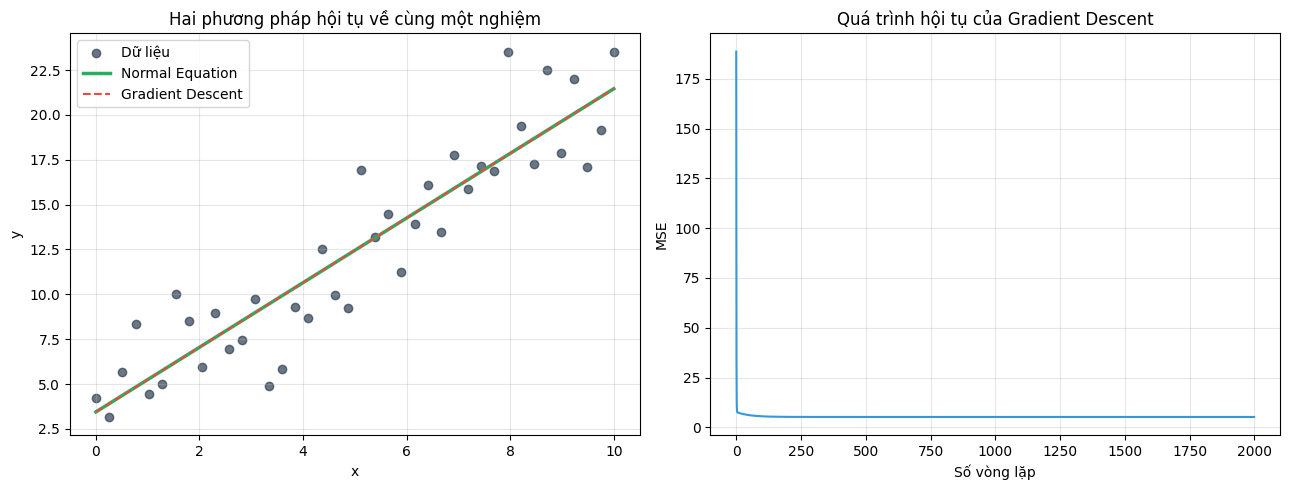

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(X, y, color="#2c3e50", alpha=0.7, label="Dữ liệu")
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
axes[0].plot(x_line, model_ne.predict(x_line), color="#27ae60", linewidth=2.5, label="Normal Equation")
axes[0].plot(x_line, model_gd.predict(x_line), color="#e74c3c", linewidth=1.5, linestyle="--", label="Gradient Descent")
axes[0].set_title("Hai phương pháp hội tụ về cùng một nghiệm")
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(model_gd.loss_history, color="#3498db")
axes[1].set_title("Quá trình hội tụ của Gradient Descent")
axes[1].set_xlabel("Số vòng lặp")
axes[1].set_ylabel("MSE")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


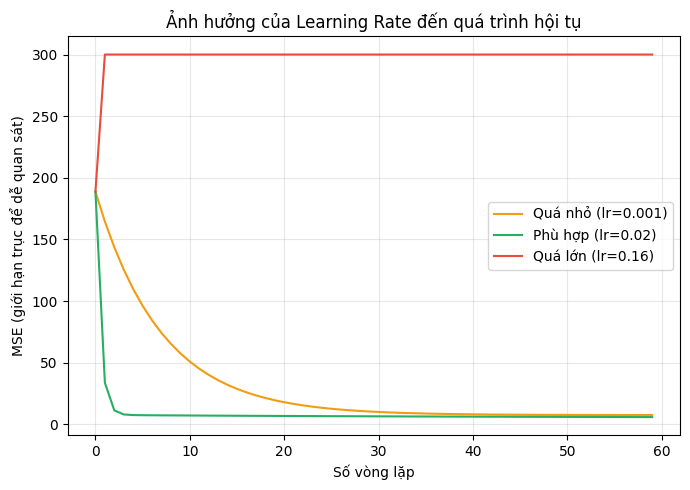

In [ ]:
learning_rates = [0.001, 0.02, 0.16]
lr_labels = ["Quá nhỏ (lr=0.001)", "Phù hợp (lr=0.02)", "Quá lớn (lr=0.16)"]
lr_colors = ["#f39c12", "#27ae60", "#e74c3c"]

fig, ax = plt.subplots(figsize=(7, 5))

for lr, label, color in zip(learning_rates, lr_labels, lr_colors):
    m = LinearRegressionScratch().fit_gradient_descent(X, y, lr=lr, n_iters=60)
    losses = np.nan_to_num(np.array(m.loss_history), nan=300.0, posinf=300.0)
    losses = np.clip(losses, 0, 300)
    ax.plot(losses, color=color, label=label)

ax.set_xlabel("Số vòng lặp")
ax.set_ylabel("MSE (giới hạn trục để dễ quan sát)")
ax.set_title("Ảnh hưởng của Learning Rate đến quá trình hội tụ")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Các metric đánh giá

### 5.1. MSE (Mean Squared Error)
$$MSE = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$$
- Đo trung bình bình phương sai số giữa giá trị dự đoán và giá trị thật.
- Vì bình phương $\rightarrow$ phạt nặng các lỗi lớn hơn nhiều so với lỗi nhỏ.
- Nhạy cảm với outlier: một điểm outlier có thể làm MSE tăng vọt, không phản ánh đúng chất lượng phần dự đoán còn lại.
- Thường được dùng trực tiếp làm loss function để tối ưu.

### 5.2. RMSE (Root Mean Squared Error)
$$RMSE = \sqrt{MSE} = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2}$$
- Đưa về cùng đơn vị với $y$ $\rightarrow$ dễ diễn giải hơn MSE.
- Vẫn giữ tính nhạy cảm với outlier.

### 5.3. MAE (Mean Absolute Error)
$$MAE = \frac{1}{N} \sum_{i=1}^{N} |y_i - \hat{y}_i|$$
- Đo trung bình giá trị tuyệt đối của sai số — mỗi điểm dữ liệu đóng góp vào metric đúng theo tỷ lệ độ lớn sai số của nó, không bị khuếch đại.
- Bền với outlier hơn MSE/RMSE: một vài điểm sai lớn không áp đảo toàn bộ metric.
- Cùng đơn vị với $y$, dễ diễn giải.
- Nhược điểm: không phân biệt được mô hình có nhiều lỗi nhỏ đều đặn với mô hình có ít lỗi nhưng một vài lỗi rất lớn.

> Nếu $RMSE \gg MAE$ trên cùng một tập dữ liệu $\rightarrow$ mô hình có một số dự đoán sai lệch rất lớn, cần kiểm tra lại (outlier, lỗi dữ liệu, ...).

### 5.4. $R^2$ – Hệ số xác định
- Nếu không biết gì về $x$, dự đoán tối ưu cho $y$ chính là giá trị trung bình $\bar{y}$. Đây là baseline cần so sánh mô hình của mình với nó.
$$\sum_{i=1}^{N}(y_i - \bar{y})^2 = \sum_{i=1}^{N}(y_i - \hat{y}_i)^2 + \sum_{i=1}^{N}(\hat{y}_i - \bar{y})^2$$
$$SS_{total} = SS_{res} + SS_{reg}$$
- $SS_{total}$: tổng bình phương biến thiên của $y$ so với $\bar{y}$.
- $SS_{reg}$: phần biến thiên mà mô hình giải thích được.
- $SS_{res}$: phần biến thiên còn sót lại mà mô hình không giải thích được (chính là tử số của MSE).
$$R^2 = \frac{SS_{reg}}{SS_{total}} = 1 - \frac{SS_{res}}{SS_{total}}$$

$R^2$ là tỷ lệ phần trăm biến thiên của $y$ mà mô hình giải thích được, so với việc không dùng mô hình gì cả (chỉ đoán $\bar{y}$):
- $R^2 = 1$: mọi dự đoán khớp hoàn toàn thực tế, mô hình giải thích được 100% biến thiên.
- $0 < R^2 < 1$: mô hình dự đoán được một phần, phần còn lại do các yếu tố mô hình không nắm bắt được (nhiễu, biến ẩn, ...).
- $R^2 = 0$: mô hình dự đoán tệ ngang việc cứ đoán $\bar{y}$ cho mọi điểm — coi như $x$ hoàn toàn vô dụng.
- $R^2 < 0$: tệ hơn cả việc đoán trung bình, chỉ xảy ra khi tập train/test quá khác biệt hoặc mô hình overfit nặng.

### 5.5. $R^2_{adj}$ – Hệ số xác định điều chỉnh
- Khi thêm feature vào mô hình, $SS_{res}$ luôn giảm (hoặc giữ nguyên), dù feature đó không có tác dụng thật sự $\Rightarrow$ $R^2$ luôn tăng khi thêm feature, tạo ảo giác mô hình khớp hoàn hảo với dữ liệu, nhưng thực chất là overfit.
- $R^2_{adj}$ khắc phục vấn đề này bằng cách phạt thêm theo số lượng feature $p$:
$$R^2_{adj} = 1 - \frac{\dfrac{SS_{res}}{n-p-1}}{\dfrac{SS_{total}}{n-1}} = 1 - (1 - R^2) \frac{n - 1}{n - p - 1}$$

In [ ]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

data = load_diabetes()
X_real, y_real = data.data, data.target

# chia tập dữ liệu ra làm test và train, test chiếm 20%
X_train, X_test, y_train, y_test = train_test_split(
    X_real, y_real, test_size=0.2, random_state=42
)

model_real = LinearRegressionScratch().fit_normal_equation(X_train, y_train)
y_pred_test = model_real.predict(X_test)

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))


def r2_score_scratch(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_total = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_total


def r2_adjusted(y_true, y_pred, n_features):
    n = len(y_true)
    r2 = r2_score_scratch(y_true, y_pred)
    return 1 - (1 - r2) * (n - 1) / (n - n_features - 1)


print("Đánh giá trên tập test (Diabetes dataset):")
print(f"  MSE     = {mse(y_test, y_pred_test):.3f}")
print(f"  RMSE    = {rmse(y_test, y_pred_test):.3f}")
print(f"  MAE     = {mae(y_test, y_pred_test):.3f}")
print(f"  R^2     = {r2_score_scratch(y_test, y_pred_test):.4f}")
print(f"  R^2_adj = {r2_adjusted(y_test, y_pred_test, X_test.shape[1]):.4f}")


Đánh giá trên tập test (Diabetes dataset):
  MSE     = 2900.194
  RMSE    = 53.853
  MAE     = 42.794
  R^2     = 0.4526
  R^2_adj = 0.3824


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Đối chiếu với scikit-learn:")
print(f"  MSE (sklearn) = {mean_squared_error(y_test, y_pred_test):.3f}")
print(f"  MAE (sklearn) = {mean_absolute_error(y_test, y_pred_test):.3f}")
print(f"  R^2 (sklearn) = {r2_score(y_test, y_pred_test):.4f}")

Đối chiếu với scikit-learn:
  MSE (sklearn) = 2900.194
  MAE (sklearn) = 42.794
  R^2 (sklearn) = 0.4526


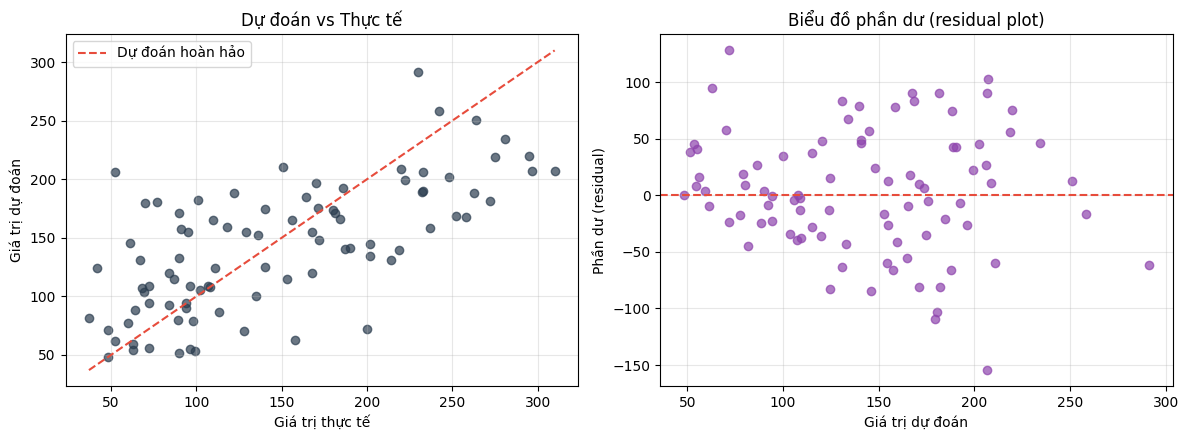

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(y_test, y_pred_test, color="#2c3e50", alpha=0.7)
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
axes[0].plot(lims, lims, color="#e74c3c", linestyle="--", label="Dự đoán hoàn hảo")
axes[0].set_xlabel("Giá trị thực tế"); axes[0].set_ylabel("Giá trị dự đoán")
axes[0].set_title("Dự đoán vs Thực tế")
axes[0].legend(); axes[0].grid(alpha=0.3)

residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals, color="#8e44ad", alpha=0.7)
axes[1].axhline(0, color="#e74c3c", linestyle="--")
axes[1].set_xlabel("Giá trị dự đoán"); axes[1].set_ylabel("Phần dư (residual)")
axes[1].set_title("Biểu đồ phần dư (residual plot)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

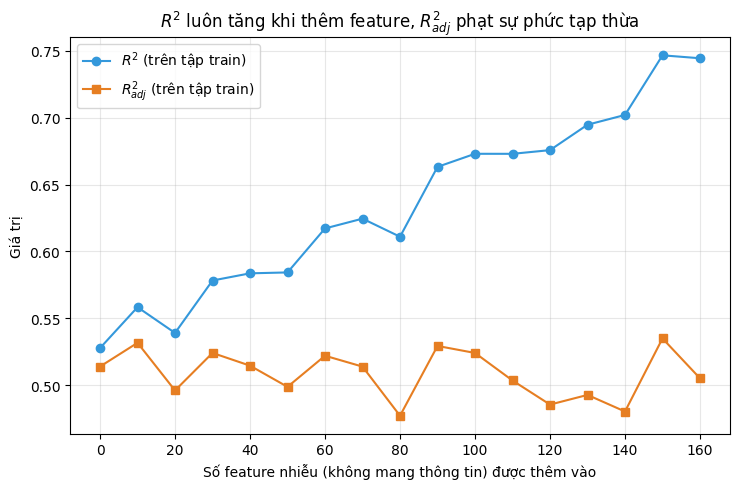

In [ ]:
# Minh họa: R^2 luôn tăng khi thêm feature nhiễu (không mang thông tin),
# trong khi R^2_adj phản ánh đúng hơn việc mô hình không thực sự tốt lên.
np.random.seed(0)
n_train = X_train.shape[0]
n_extra_list = list(range(0, 161, 10))
r2_list, r2_adj_list = [], []

for k in n_extra_list:
    noise_feats = np.random.normal(0, 1, (n_train, k))
    X_aug = np.hstack([X_train, noise_feats])

    m = LinearRegressionScratch().fit_normal_equation(X_aug, y_train)
    y_pred_train = m.predict(X_aug)

    r2_list.append(r2_score_scratch(y_train, y_pred_train))
    r2_adj_list.append(r2_adjusted(y_train, y_pred_train, X_aug.shape[1]))

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(n_extra_list, r2_list, marker="o", color="#3498db", label="$R^2$ (trên tập train)")
ax.plot(n_extra_list, r2_adj_list, marker="s", color="#e67e22", label="$R^2_{adj}$ (trên tập train)")
ax.set_xlabel("Số feature nhiễu (không mang thông tin) được thêm vào")
ax.set_ylabel("Giá trị")
ax.set_title("$R^2$ luôn tăng khi thêm feature, $R^2_{adj}$ phạt sự phức tạp thừa")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Nhiễu outlier
Nhiễu outlier (ngoại lệ) là các điểm dữ liệu có giá trị khác biệt quá lớn hoặc nằm cách vị trí của phần lớn các quan sát còn lại trong tập dữ liệu một khoảng bất thường.
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$
Vì sai số $(y_i - \hat{y}_i)$ được bình phương, một điểm outlier (có sai số rất lớn) sẽ bị khuếch đại lên gấp nhiều lần. Để giảm thiểu tổng sai số khổng lồ này, đường thẳng hồi quy sẽ bị "bẻ cong" và kéo lệch về phía outlier, dẫn đến việc mô hình dự đoán sai cho toàn bộ phần lớn dữ liệu chuẩn
## Các cách khắc phục Outlier trong Linear Regression
- Xử lý dữ liệu trước khi training (Data Preprocessing)
- Thay thuật toán: thay vì dùng MSE có thể thay bằng MAE hoặc Huber (MSE cho dữ liệu sai số nhỏ, MAE với dữ liệu sai số lớn)

## 6. Polynomials regression
### 6.1. Định nghĩa
Hồi quy tuyến tính giả định mối quan hệ giữa x và y là tuyến tính, nhưng nhiều hiện tượng thực tế có quan hệ phi tuyến tính. Hồi quy đa thức mở rộng mô hình bằng cách thêm các lũy thừa của x làm đặc trưng:
$$y=\beta_{0}+\beta_{1}x+\beta_{2}x^2+\beta_{3}x^3+...+\beta_{d}x^d + \epsilon$$
Đây vẫn là mô hình tuyến tính — không phải theo $x$, mà tuyến tính theo các hệ số $\beta$
. Ta chỉ đang biến đổi đặc trưng đầu vào ($x \to [x, x^2, x^3, \dots]$), sau đó áp dụng hồi quy tuyến tính bình thường lên không gian đặc trưng mớ
### 6.2. Biểu diễn ma trận
Với $n$ điểm dữ liệu và bậc đa thức $d$, ma trận thiết kế (design matrix) là:

$$
X = \begin{bmatrix}
1 & x_1 & x_1^2 & \dots & x_1^d \\
1 & x_2 & x_2^2 & \dots & x_2^d \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_n & x_n^2 & \dots & x_n^d
\end{bmatrix} \in \mathbb{R}^{n \times (d+1)}
$$

Ma trận này gọi là \textbf{ma trận Vandermonde}. Nghiệm tối ưu vẫn theo công thức normal equation:

$$
\hat{\beta} = (X^T X)^{-1} X^T y
$$

hoặc dùng gradient descent nếu $d + 1$ lớn hoặc $X^T X$ gần suy biến.

### 6.3. Chọn bậc đa thức $d$: Bias–Variance Tradeoff

Đây là câu hỏi trung tâm của hồi quy đa thức.

| Bậc $d$ | Bias | Variance | Hiện tượng |
|---|---|---|---|
| Quá thấp | Cao | Thấp | Underfit |
| Vừa đủ | Thấp | Vừa | Tốt |
| Quá cao | Rất thấp | Cao | Overfit |

Khi $d$ lớn, đa thức có thể đi qua gần như chính xác mọi điểm (nội suy) $\rightarrow$ train error $\approx 0$ nhưng test error rất lớn.

- Overfitting (Quá khớp) là tình trạng một mô hình học máy học quá sát với dữ liệu huấn luyện (training data), đến mức nó "ghi nhớ" cả những nhiễu loạn (noise), sai số đo lường và các chi tiết ngẫu nhiên thay vì tìm ra quy luật tổng quát.

$\rightarrow$ Kết quả là mô hình có độ chính xác gần như tuyệt đối trên tập dữ liệu đã học, nhưng lại thất bại hoàn toàn (cho kết quả dự đoán sai lệch lớn) khi áp dụng vào dữ liệu mới, dữ liệu thực tế hoặc tập kiểm thử (test data).

- Underfitting (Chưa khớp) là tình trạng mô hình học máy quá đơn giản hoặc chưa được học đủ để nắm bắt được quy luật ẩn chứa bên trong dữ liệu. Nó giống như việc bạn cố nhìn cả thế giới qua một cái ống hút vậy – góc nhìn quá hạn hẹp.

$\rightarrow$ Hậu quả là mô hình không thể dự đoán tốt ngay cả trên dữ liệu mà nó vừa được học (training data), và đương nhiên cũng sẽ dự đoán rất tệ trên dữ liệu thực tế (test data).

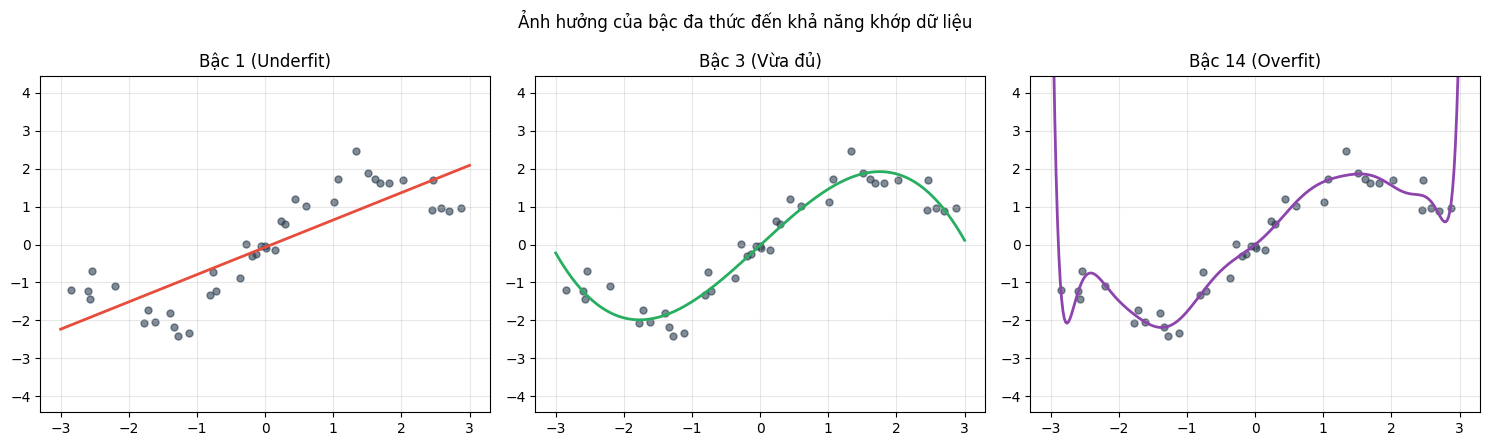

In [ ]:
def polynomial_features(x, deg):
  x = np.asarray(x).reshape(-1, 1)
  return np.hstack([x ** d for d in range(1, deg + 1)])

def fit_polynomial(x, y, deg):
  X_poly = polynomial_features(x, deg)
  return LinearRegressionScratch().fit_normal_equation(X_poly, y)

np.random.seed(7)
n_pts = 40
x_poly = np.sort(np.random.uniform(-3, 3, n_pts))
y_poly = 2 * np.sin(x_poly) + np.random.normal(0, 0.3, n_pts)

degrees_to_show = [1, 3, 14]
titles = ["Bậc 1 (Underfit)", "Bậc 3 (Vừa đủ)", "Bậc 14 (Overfit)"]
poly_colors = ["#e74c3c", "#27ae60", "#8e44ad"]

x_plot = np.linspace(-3, 3, 300)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, d, title, color in zip(axes, degrees_to_show, titles, poly_colors):
    model = fit_polynomial(x_poly, y_poly, d)
    y_plot = model.predict(polynomial_features(x_plot, d))
    ax.scatter(x_poly, y_poly, color="#2c3e50", alpha=0.6, s=25)
    ax.plot(x_plot, y_plot, color=color, linewidth=2)
    ax.set_title(title)
    ax.set_ylim(y_poly.min() - 2, y_poly.max() + 2)
    ax.grid(alpha=0.3)

plt.suptitle("Ảnh hưởng của bậc đa thức đến khả năng khớp dữ liệu")
plt.tight_layout()
plt.show()

**Cách tìm $d$ tối ưu:**

**K-Fold Cross-Validation**
- Cho $d$ chạy từ 1 đến một giới hạn nào đó (ví dụ $1, 2, \dots, 15$).
- Với mỗi giá trị $d$, huấn luyện và đánh giá mô hình $K$ lần (mỗi lần lấy 1 phần làm validation, $K-1$ phần còn lại để train).
- Tính trung bình sai số (thường là MSE) trên tập validation cho $d$ đó.
- Chọn $d$ mang lại sai số validation trung bình thấp nhất.

**Vẽ đồ thị sai số (Validation Curve)**
- Trục X: bậc đa thức $d$; trục Y: sai số (MSE); hai đường: Training Error và Validation Error.
- Chọn điểm đáy của đường Validation Error — nơi mô hình tổng quát hóa tốt nhất trên dữ liệu chưa từng thấy.

**Dùng bậc cao kết hợp Regularization**
- Chọn bậc đa thức tương đối cao ($d=10, 20, \dots$), cố tình đẩy mô hình về hướng overfitting.
- Sau đó dùng Regularization (L2/Ridge hoặc L1/Lasso) gắn vào hàm mất mát để tự động kéo các hệ số bậc cao, dư thừa về gần 0 (xem Mục 7).


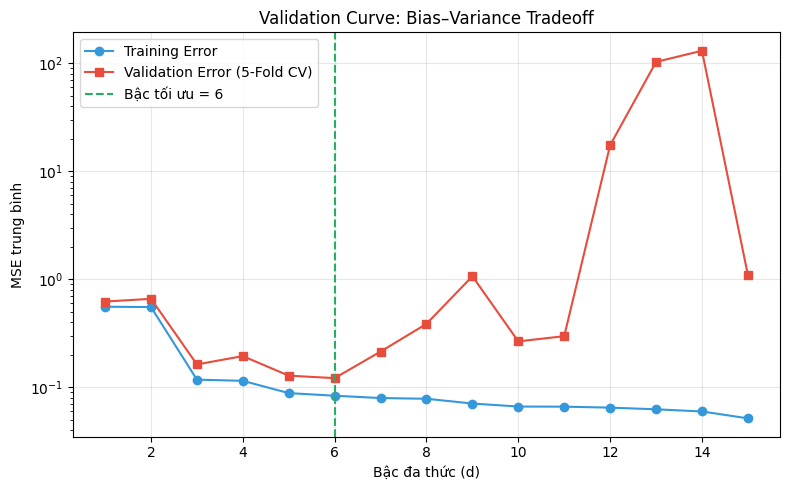

Bậc đa thức tối ưu theo Cross-Validation: d = 6


In [ ]:
from sklearn.model_selection import KFold

degrees = list(range(1, 16))
train_errors, val_errors = [], []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for d in degrees:
  X_full = polynomial_features(x_poly, d)
  fold_train, fold_val = [], []
  for train_idx, val_idx in kf.split(X_full):
      model = LinearRegressionScratch().fit_normal_equation(
          X_full[train_idx], y_poly[train_idx]
      )
      train_pred = model.predict(X_full[train_idx])
      val_pred = model.predict(X_full[val_idx])
      fold_train.append(mse(y_poly[train_idx], train_pred))
      fold_val.append(mse(y_poly[val_idx], val_pred))
  train_errors.append(np.mean(fold_train))
  val_errors.append(np.mean(fold_val))

best_degree = degrees[int(np.argmin(val_errors))]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(degrees, train_errors, marker="o", color="#3498db", label="Training Error")
ax.plot(degrees, val_errors, marker="s", color="#e74c3c", label="Validation Error (5-Fold CV)")
ax.axvline(best_degree, color="#27ae60", linestyle="--", label=f"Bậc tối ưu = {best_degree}")
ax.set_xlabel("Bậc đa thức (d)")
ax.set_ylabel("MSE trung bình")
ax.set_yscale("log")
ax.set_title("Validation Curve: Bias–Variance Tradeoff")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Bậc đa thức tối ưu theo Cross-Validation: d = {best_degree}")

## 7. Regularization l1, l2
Regularization (Điều chuẩn) là một kỹ thuật cực kỳ quan trọng trong học máy, được sử dụng để giải quyết vấn đề Overfitting (Quá khớp)
### 7.1 l1 Regularization
L1 Regularization (còn gọi là thuật toán Lasso - Least Absolute Shrinkage and Selection Operator) sử dụng khoản phạt là tổng giá trị tuyệt đối của các hệ số trọng lượng $\beta$.
$$Loss = \text{MSE} + \lambda \sum_{i=1}^n \vert{}\beta_i\vert{}$$
- $\lambda$ (Lambda): Là tham số điều chuẩn, $\lambda$ càng lớn, hình phạt càng nặng.
-  L1 có xu hướng ép các trọng số $\beta$ của những biến đầu vào không quan trọng (hoặc các biến nhiễu) về chính xác bằng 0 (Feature Selectio)
-  Kết quả: Thuật toán trả về một mô hình thưa thớt (sparse model). có thể vứt bỏ hoàn toàn các đặc trưng có trọng số bằng 0, giúp giảm chiều dữ liệu.

### 7.2. L2 Regularization
L2 Regularization (còn gọi là thuật toán Ridge Regression) sử dụng khoản phạt là tổng bình phương của các hệ số trọng lượng $\beta$.
$$Loss = \text{MSE} + \lambda \sum_{i=1}^n \beta_i^2$$
- Vì sử dụng bình phương, L2 sẽ phạt rất nặng những trọng số có giá trị lớn. Nó kéo tất cả các trọng số $\beta$ tiến sát về 0, nhưng hầu như không bao giờ bằng đúng 0
- L2 buộc mô hình phải dàn trải trọng số đều hơn cho các biến, không tập trung vào một biến duy nhất
$$L_{Ridge}(w) = \vert{}\vert{}y - Xw\vert{}\vert{}^2 + \lambda \vert{}\vert{}w\vert{}\vert{}^2$$
$$L(w) = (y - Xw)^T (y - Xw) + \lambda (w^T w)$$
$$L(w) = y^T y - y^T Xw - w^T X^T y + w^T X^T X w + \lambda w^T w$$
$$L(w) = y^T y - 2w^T X^T y + w^T X^T X w + \lambda w^T w$$
$$\frac{\partial L(w)}{\partial w} = -2X^T y + 2X^T X w + 2\lambda I w = 0$$
$$w = (X^T X + \lambda I)^{-1} X^T y$$

In [ ]:
class RidgeRegressionScratch:
  def __init__(self, lam=1.0):
    self.lam = lam
    self.w = None

  def fit(self, X, y):
    n_samples, n_features = X.shape
    Xb = np.hstack([np.ones((n_samples, 1)), X])
    I = np.eye(n_features + 1)
    I[0, 0] = 0
    self.w = np.linalg.inv(Xb.T @ Xb + self.lam * I) @ Xb.T @ y
    return self

  def predict(self, X):
    Xb = np.hstack([np.ones((X.shape[0], 1)), X])
    return Xb @ self.w

class LassoRegressionScratch:
  def __init__(self, lam=1.0, n_iters=1000, tol=1e-6):
    self.lam = lam
    self.n_iters = n_iters
    self.tol = tol
    self.w = None

  @staticmethod
  def _soft_threshold(rho, lam):
    if rho < -lam:
      return rho + lam
    if rho > lam:
      return rho - lam
    return 0

  def fit(self, X, y):
    n_samples = X.shape[0]
    Xb = np.hstack([np.ones((X.shape[0], 1)), X])
    w = np.zeros(Xb.shape[1])
    for _ in range(self.n_iters):
      w_old = w.copy()
      for j in range(Xb.shape[1]):
        Xj = Xb[:, j]
        res = y - (Xb @ w - Xj * w[j])
        rho = Xj @ res
        z = Xj @ Xj
        if j == 0:
          w[j] = rho / z
        else:
          w[j]= self._soft_threshold(rho, self.lam * n_samples) / z

      if np.linalg.norm(w - w_old) < self.tol:
        break

    self.w = w
    return self

  def predict(self, X):
    return np.hstack([np.ones((X.shape[0], 1)), X]) @ self.w

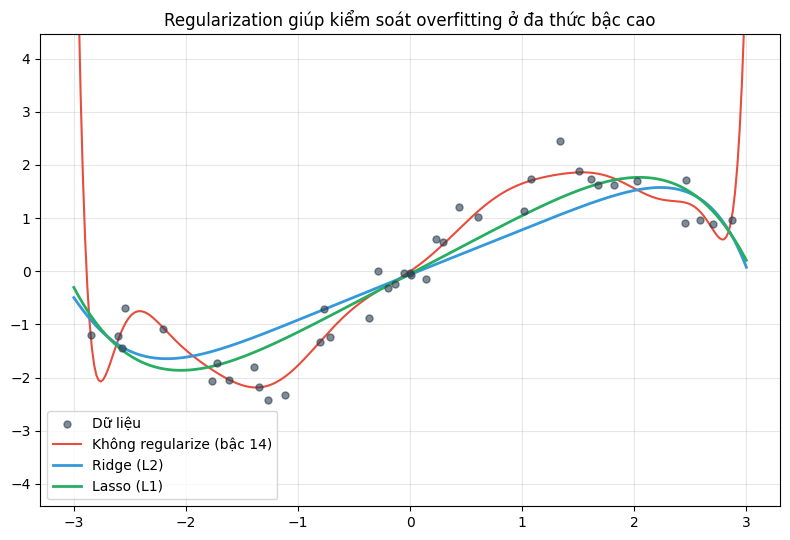

In [ ]:
deg = 14
X_poly = polynomial_features(x_poly, deg)
X_mean, X_std = X_poly.mean(axis=0), X_poly.std(axis=0)
X_poly = (X_poly - X_mean) / X_std

model_overfit = LinearRegressionScratch().fit_normal_equation(X_poly, y_poly)
model_ridge = RidgeRegressionScratch(lam=5.0).fit(X_poly, y_poly)
model_lasso = LassoRegressionScratch(lam=0.05, n_iters=3000).fit(X_poly, y_poly)

def prep(x):
    Xp = polynomial_features(x, deg)
    return (Xp - X_mean) / X_std

X_plot_scaled = prep(x_plot)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(x_poly, y_poly, color="#2c3e50", alpha=0.6, s=25, label="Dữ liệu", zorder=3)
ax.plot(x_plot, model_overfit.predict(X_plot_scaled), color="#e74c3c", label=f"Không regularize (bậc {deg})")
ax.plot(x_plot, model_ridge.predict(X_plot_scaled), color="#3498db", linewidth=2, label="Ridge (L2)")
ax.plot(x_plot, model_lasso.predict(X_plot_scaled), color="#27ae60", linewidth=2, label="Lasso (L1)")
ax.set_ylim(y_poly.min() - 2, y_poly.max() + 2)
ax.set_title("Regularization giúp kiểm soát overfitting ở đa thức bậc cao")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Tổng kết

| Thành phần | Tóm tắt |
|---|---|
| Mô hình | Quan hệ tuyến tính giữa $X$ và $y$: $\hat{y} = Xw$ |
| Hàm mất mát | MSE — suy ra trực tiếp từ MLE với giả định nhiễu Gauss |
| Tối ưu | Normal Equation (closed-form, $O(p^3)$) hoặc Gradient Descent (lặp, mở rộng tốt hơn khi $N, p$ lớn) |
| Đánh giá | MSE/RMSE/MAE (đo theo đơn vị sai số), $R^2$/$R^2_{adj}$ (đo mức độ giải thích biến thiên) |
| Mở rộng phi tuyến | Polynomial Regression — vẫn là mô hình tuyến tính theo hệ số $\beta$ |
| Kiểm soát overfitting | Regularization: L1/Lasso (sparse, chọn feature) và L2/Ridge (co đều, ổn định) |

**Một số lưu ý khi áp dụng thực tế:**
- Luôn chuẩn hóa (standardize) đặc trưng trước khi dùng Regularization, vì L1/L2 rất nhạy với thang đo.
- Dùng Cross-Validation để chọn bậc đa thức $d$ và hệ số $\lambda$, tránh chọn theo cảm tính.
- $R^2$ chỉ nên dùng để so sánh các mô hình có cùng tập dữ liệu; khi số lượng feature khác nhau, nên ưu tiên $R^2_{adj}$ để tránh ảo giác overfit.
- Khi tập dữ liệu có $N, p$ đều lớn, Gradient Descent (hoặc các biến thể như Mini-batch GD, Adam) thường được ưu tiên hơn Normal Equation, do chi phí $O(p^3)$ của phép nghịch đảo ma trận trở nên quá tốn kém.

# Cây quyết định và rừng ngẫu nhiên
## 1. Mô hình
### 1.1. Cây quyết định là gì?

Cây quyết định là mô hình **phi tham số** (non-parametric), dự đoán bằng cách chia không gian đặc trưng
$\mathbb{R}^d$ thành các **vùng hình chữ nhật** (axis-aligned regions) $R_1, R_2, \dots, R_M$ thông qua một chuỗi
câu hỏi dạng "$x_j \le t$?" được tổ chức thành cấu trúc cây nhị phân.

- **Internal node (nút trong):** chứa một điều kiện chia $(x_j \le t)$
- **Leaf node (nút lá):** chứa giá trị dự đoán — hằng số cho vùng đó
  - Classification: nhãn phổ biến nhất (majority vote) hoặc phân phối xác suất theo tần suất lớp
  - Regression: trung bình (hoặc trung vị) của các nhãn $y$ trong vùng
  
Khác với hồi quy tuyến tính (một hàm tuyến tính toàn cục), cây quyết định là **local, adaptive**: mỗi vùng
$R_m$ có một hằng số dự đoán riêng, ranh giới quyết định là các đường/mặt vuông góc với trục toạ độ.
### 1.2. Loại bài toán áp dụng

| Bài toán | Đầu ra $y$ | Giá trị tại lá | Độ đo impurity dùng để chia |
|---|---|---|---|
| **Classification** | Nhãn rời rạc $\{1,\dots,K\}$ | Lớp đa số / phân phối xác suất | Gini, Entropy, Classification error |
| **Regression** | Giá trị liên tục $\mathbb{R}$ | Trung bình $\bar y$ trong vùng | MSE (variance), MAE |

Cây quyết định dùng được cho **cả hai** loại bài toán chỉ bằng cách đổi độ đo impurity — thuật toán xây cây
(CART) là như nhau.
### 1.3. Random Forest

Random Forest là **ensemble** gồm nhiều cây quyết định độc lập, mỗi cây được huấn luyện trên:
- Một mẫu bootstrap khác nhau của dữ liệu (Bagging)
- Một tập con ngẫu nhiên các đặc trưng tại mỗi lần chia (feature randomness)

rồi **tổng hợp dự đoán** bằng vote đa số (classification) hoặc trung bình (regression). Ý tưởng cốt lõi:
mỗi cây riêng lẻ có **variance cao** (dễ overfit), nhưng trung bình của nhiều cây **ít tương quan** với nhau
sẽ giảm variance mà không tăng bias

## 2. Thuật toán xây dựng cây
### 2.1. Bài toán tại mỗi node: tìm điểm chia tốt nhất

Tại một node chứa tập dữ liệu $D$ với $N$ mẫu, thuật toán tìm cặp (đặc trưng $j$, ngưỡng $t$) sao cho khi
chia $D$ thành:

$$
D_{\text{left}} = \{(x,y) \in D : x_j \le t\}, \qquad D_{\text{right}} = \{(x,y) \in D : x_j > t\}
$$

thì độ giảm impurity (impurity decrease) là lớn nhất:

$$
\Delta I(j, t) = I(D) - \left( \frac{N_{\text{left}}}{N} I(D_{\text{left}}) + \frac{N_{\text{right}}}{N} I(D_{\text{right}}) \right)
$$

trong đó $I(\cdot)$ là độ đo bất thuần khiết (impurity measure). Thuật toán duyệt qua mọi đặc trưng và
mọi ngưỡng chia khả dĩ (thường là trung điểm giữa các giá trị liên tiếp sau khi sắp xếp), chọn cặp $(j,t)$
cho $\Delta I$ lớn nhất — đây là bước tham lam (greedy): chỉ tối ưu cục bộ tại node hiện tại, không nhìn xa
hơn (không tối ưu toàn cục cho cả cây).
### 2.2. Độ đo Impurity cho Classification

Gọi $p_k$ là tỉ lệ mẫu thuộc lớp $k$ trong node ($k = 1,\dots,K$).

Classification error:
$$
I_{\text{error}} = 1 - \max_k p_k
$$

Gini impurity (CART mặc định) — xác suất phân loại sai nếu gán nhãn ngẫu nhiên theo phân phối $p_k$:
$$
I_{\text{Gini}} = \sum_{k=1}^{K} p_k(1-p_k) = 1 - \sum_{k=1}^{K} p_k^2
$$

Entropy (dùng trong ID3/C4.5) — bắt nguồn từ lý thuyết thông tin, đo lượng hỗn loạn:
$$
I_{\text{Entropy}} = -\sum_{k=1}^{K} p_k \log_2 p_k
$$
### 2.3. Độ đo Impurity cho Regression

Thay vì phân phối lớp, tại mỗi node ta có tập giá trị liên tục $\{y_i\}$. Impurity phổ biến nhất là
phương sai (variance), tương đương MSE quanh trung bình:

$$
I_{\text{MSE}}(D) = \frac{1}{N}\sum_{i \in D} (y_i - \bar y_D)^2, \qquad \bar y_D = \frac{1}{N}\sum_{i\in D} y_i
$$

Điểm chia tốt nhất là điểm giảm phương sai nhiều nhất (variance reduction) — hoàn toàn tương tự công thức
$\Delta I$ ở trên.
### 2.4. Thuật toán tổng quát (đệ quy)

```
BUILD_TREE(D, depth):
    if điều kiện dừng thỏa mãn (xem 2.6):
        return Leaf(giá trị dự đoán = majority/mean của D)

    best_gain = -inf
    for mỗi đặc trưng j:
        for mỗi ngưỡng t trong các giá trị khả dĩ của x_j:
            gain = ΔI(j, t)
            if gain > best_gain: lưu lại (j, t, gain)

    if best_gain <= 0 (hoặc < min_impurity_decrease):
        return Leaf(...)

    D_left, D_right = chia D theo (j*, t*)
    left  = BUILD_TREE(D_left,  depth+1)
    right = BUILD_TREE(D_right, depth+1)
    return Node(j*, t*, left, right)
```

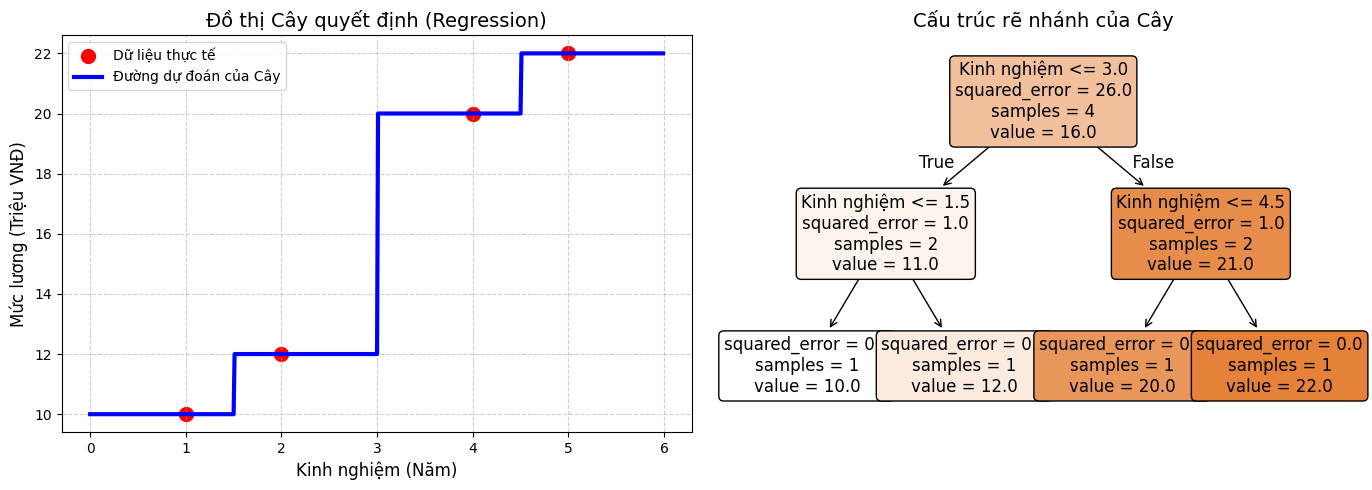

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree

X_train = np.array([[1], [2], [4], [5]])
y_train = np.array([10, 12, 20, 22])

tree_reg = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg.fit(X_train, y_train)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)

X_grid = np.arange(0, 6, 0.01)[:, np.newaxis]
y_pred_grid = tree_reg.predict(X_grid)

plt.scatter(X_train, y_train, color='red', s=100, label='Dữ liệu thực tế')
plt.plot(X_grid, y_pred_grid, color='blue', linewidth=3, label='Đường dự đoán của Cây')

plt.title('Đồ thị Cây quyết định (Regression)', fontsize=14)
plt.xlabel('Kinh nghiệm (Năm)', fontsize=12)
plt.ylabel('Mức lương (Triệu VNĐ)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
tree.plot_tree(
    tree_reg,
    feature_names=['Kinh nghiệm'],
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title('Cấu trúc rẽ nhánh của Cây', fontsize=14)

plt.tight_layout()
plt.show()

Độ chính xác của mô hình: 93.33%


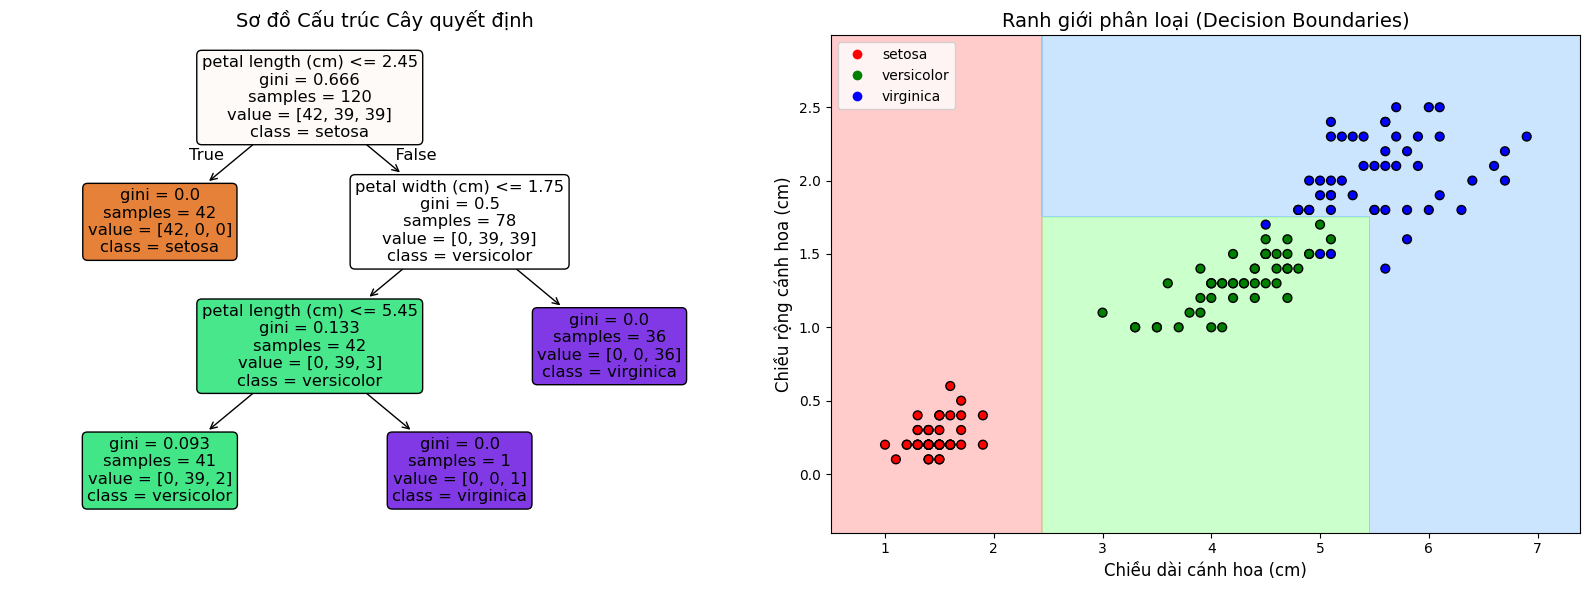

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

iris = load_iris()
X = iris.data[:, 2:]
y = iris.target

# Chia dữ liệu: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

tree_clf = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    min_samples_split=4,
    random_state=42
)
tree_clf.fit(X_train, y_train)

# Đánh giá độ chính xác
do_chinh_xac = tree_clf.score(X_test, y_test)
print(f"Độ chính xác của mô hình: {do_chinh_xac * 100:.2f}%")

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plot_tree(
    tree_clf,
    feature_names=iris.feature_names[2:],
    class_names=iris.target_names,
    filled=True,
    rounded=True
)
plt.title("Sơ đồ Cấu trúc Cây quyết định", fontsize=14)

plt.subplot(1, 2, 2)

x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

Z = tree_clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

cmap_background = ListedColormap(['#ff9999', '#99ff99', '#99ccff'])
plt.contourf(xx, yy, Z, alpha=0.5, cmap=cmap_background)

cmap_points = ListedColormap(['red', 'green', 'blue'])
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_points, edgecolors='k', s=40)

plt.xlabel('Chiều dài cánh hoa (cm)', fontsize=12)
plt.ylabel('Chiều rộng cánh hoa (cm)', fontsize=12)
plt.title("Ranh giới phân loại (Decision Boundaries)", fontsize=14)
plt.legend(handles=scatter.legend_elements()[0], labels=list(iris.target_names), loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

iris = load_iris()
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

# 2. Khởi tạo mô hình Random Forest
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    max_features='sqrt',
    bootstrap=True,
    random_state=42
)

rf_clf.fit(X_train, y_train)

y_pred = rf_clf.predict(X_test)
print(f"Độ chính xác của Random Forest: {accuracy_score(y_test, y_pred) * 100:.2f}%")

print("\nMức độ quan trọng của các đặc trưng:")
for name, score in zip(iris.feature_names, rf_clf.feature_importances_):
    print(f"- {name}: {score:.4f}")

Độ chính xác của Random Forest: 90.00%

Mức độ quan trọng của các đặc trưng:
- sepal length (cm): 0.0991
- sepal width (cm): 0.0154
- petal length (cm): 0.4182
- petal width (cm): 0.4672


In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor

X_train = np.array([[1], [2], [4], [5]])
y_train = np.array([10, 12, 20, 22])

rf_reg = RandomForestRegressor(
    n_estimators=50,
    max_depth=1,
    random_state=42
)

rf_reg.fit(X_train, y_train)

X_new = np.array([[2.5]])
luong_du_doan = rf_reg.predict(X_new)

print(f"Random Forest dự đoán lương cho 2.5 năm kinh nghiệm: {luong_du_doan[0]:.2f} triệu VNĐ")

Random Forest dự đoán lương cho 2.5 năm kinh nghiệm: 11.98 triệu VNĐ
